## Evaluator - Optimizer workflow

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [3]:
from typing_extensions import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [11]:
class State(TypedDict):
    topic: str
    joke: str
    feedback: str
    isfunny: Literal[True, False]

class Feedback(BaseModel):
    isfunny: Literal[True, False] = Field(description='Decide if the joke was funny and dark or not')
    feedback: str = Field(description='If the joke is not funny or dark, provide feedback on how to improve it in short')

eval_model = model.with_structured_output(Feedback)

In [19]:
def generate_joke(state: State) -> State:
    if state.get('feedback'):
        result = model.invoke(f'Write a joke about {state['topic']} but take the previous joke in account {state['joke']} with the feedback: {state['feedback']}')
    else: 
        result = model.invoke(f"Write a joke about {state['topic']}")
    
    return {'joke': result.content}

def joke_evaluator(state: State) -> State:
    result = eval_model.invoke(
        f"Evaluate the following joke and determine if it is dark and funny or not: {state['joke']} \
        If the joke is not dark and funny, provide feedback on how to improve it."
    )
    return {"isfunny": result.isfunny, "feedback": result.feedback}

def route_decision(state: State) -> Literal['end', 'retry']:
    if state['isfunny'] :
        return 'end'
    else:
        return 'retry'

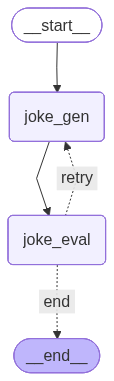

In [20]:
builder = StateGraph(State)
builder.add_node('joke_gen', generate_joke)
builder.add_node('joke_eval', joke_evaluator)

builder.add_edge(START, 'joke_gen')
builder.add_edge('joke_gen', 'joke_eval')
builder.add_conditional_edges(
    'joke_eval',
    route_decision,
    {
        'retry': 'joke_gen',
        'end': END
    }
)

flow = builder.compile(debug = True)
flow

In [21]:
result = flow.invoke({'topic': 'Arya Stark'})
result

[values] {'topic': 'Arya Stark'}
[updates] {'joke_gen': {'joke': 'Why doesn’t Arya Stark ever lose at card games?\n\nBecause if you’re on her list, you’re already out of the deck.'}}
[values] {'topic': 'Arya Stark', 'joke': 'Why doesn’t Arya Stark ever lose at card games?\n\nBecause if you’re on her list, you’re already out of the deck.'}
[updates] {'joke_eval': {'isfunny': True, 'feedback': ''}}
[values] {'topic': 'Arya Stark', 'joke': 'Why doesn’t Arya Stark ever lose at card games?\n\nBecause if you’re on her list, you’re already out of the deck.', 'feedback': '', 'isfunny': True}


{'topic': 'Arya Stark',
 'joke': 'Why doesn’t Arya Stark ever lose at card games?\n\nBecause if you’re on her list, you’re already out of the deck.',
 'feedback': '',
 'isfunny': True}

In [22]:
display(Markdown(f"### Final Joke:\n{result['joke']}"))

### Final Joke:
Why doesn’t Arya Stark ever lose at card games?

Because if you’re on her list, you’re already out of the deck.